In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# function for sigmoid to call it later easily, it makes the result between 0 and 1
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [3]:
#sigmoid derivative, it measures the error
def gradient(x):
    return x*(1-x)

In [4]:
#input array where it shows diff cases for xor
x = np.array([[1,1],
             [1,0],
             [0,1],
             [0,0]])

In [5]:
#output array showing what each input resulted in, to train the model
y = np.array([[0], [1], [1], [0]])

In [6]:
# this for stable outcome in each run, it gives the starting point
np.random.seed(42)
#initailize the weights
weight0 = (2*np.random.random((2, 4))-1)
weight1 = (2*np.random.random((4,1))-1)

In [7]:
# a loop for propagation
# in each turn it learns better and adjusts the weight at the end of the cylce
# that's y we didn't define the weights here, it'll make it lose all the progress
#i needed a huge range to make it learn cause the LR is so low as requested
count = 0
loss_curve = []
for epoch in range(10000):
    learning_rate = 0.1

    #layer0 is input x, layer1 is hidden layer, layer2 is output
    layer_0 = x
    layer_1 = sigmoid(np.dot(layer_0,weight0))
    layer_2 = sigmoid(np.dot(layer_1, weight1))

    #this calculates the diff between the ideal result and ours and defining mean squared error for result
    error = y - layer_2
    mse = np.mean(error**2)

    #optimizing
    output_mistakes = error*gradient(layer_2)
    # this calculates how much error was caused by each neuron in the hidden layer
    hidden_mistakes = np.dot(output_mistakes, weight1.T)
    layer1_mistakes = hidden_mistakes*gradient(layer_1)
    
    #gradually making the weights better
    weight1 += np.dot(layer_1.T ,output_mistakes) * learning_rate
    weight0 += np.dot(layer_0.T,layer1_mistakes )*learning_rate

    #collecting mse over the loop for curve loss graph
    loss_curve.append(mse)
    if epoch % 500 == 0:
        count += 500
        print(f'Mean squared error in round {count}: \n{(mse):.4f}\n')

Mean squared error in round 500: 
0.2629

Mean squared error in round 1000: 
0.2498

Mean squared error in round 1500: 
0.2485

Mean squared error in round 2000: 
0.2456

Mean squared error in round 2500: 
0.2372

Mean squared error in round 3000: 
0.2190

Mean squared error in round 3500: 
0.1925

Mean squared error in round 4000: 
0.1534

Mean squared error in round 4500: 
0.1072

Mean squared error in round 5000: 
0.0734

Mean squared error in round 5500: 
0.0525

Mean squared error in round 6000: 
0.0390

Mean squared error in round 6500: 
0.0295

Mean squared error in round 7000: 
0.0225

Mean squared error in round 7500: 
0.0173

Mean squared error in round 8000: 
0.0135

Mean squared error in round 8500: 
0.0109

Mean squared error in round 9000: 
0.0090

Mean squared error in round 9500: 
0.0077

Mean squared error in round 10000: 
0.0066



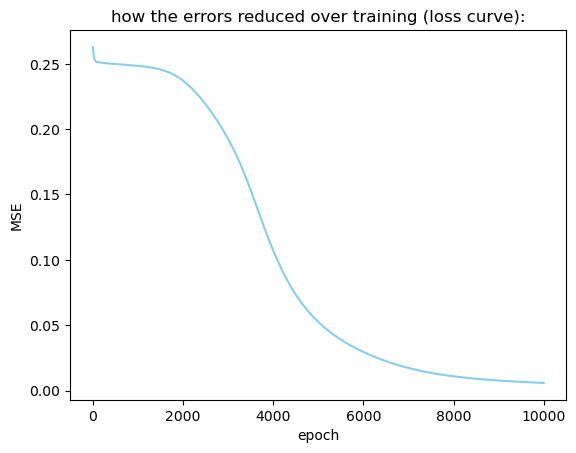

In [8]:
# now we represent that loss b4 showing what it resulted in at the end
plt.Figure(figsize=(18,6))
plt.plot(loss_curve, color = 'skyblue')
plt.title('how the errors reduced over training (loss curve):')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.show()

In [9]:
#layer 2 is the output, y is the ideal answer, they're so close to y so it's correct
print("result:", layer_2)

result: [[0.07104899]
 [0.91283456]
 [0.95692784]
 [0.09396352]]
